# 03b-07 - Orthomosaic

You make an orthophoto from one photograph and the surface model of your flight, and you see why roofs lean on a terrain model.

We start with the orthomosaic of the whole flight. Then we pick the photograph that sees the window best. We lay it onto the surface model, add a second photograph and set the software's mosaic beside ours. At the end the roof leans again, on the terrain model and on flat ground.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm
import shapely

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## The orthomosaic of the whole flight

The cell opens the orthomosaic of the whole flight and marks the window, and it loads the block, the two height models and the photograph the later sections use.

the orthomosaic, 3741 by 2777 cells of 10 cm   reference 10 cm


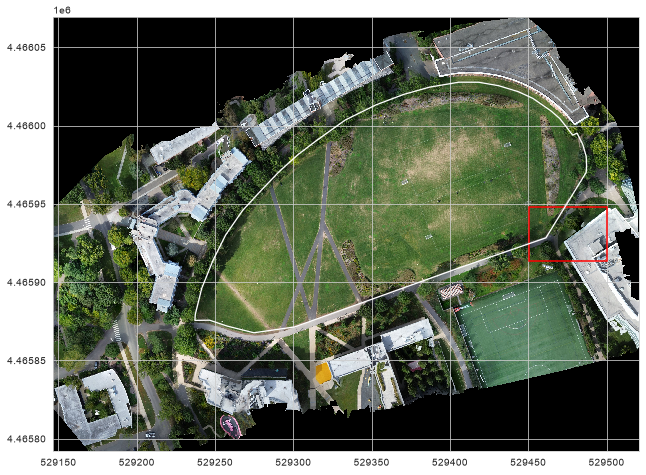

In [2]:
ortho, ortho_transform, crs, cell_whole = sfm.read_raster("data/ortho_10cm.tif")
field = gpd.read_file("data/site.gpkg", layer="site").to_crs(crs)
block = sfm.load_block("data/block.npz")
dsm, transform, crs, cell = sfm.read_raster("data/dsm_window.tif")
dtm = sfm.read_raster("data/dtm_window.tif")[0]
image_a = sfm.read_image("data/photo_a.jpg")
rotation, translation = block["rotation_map"], block["translation_map"]
camera, offset = block["camera"], choices["offset"]
fig, ax = plt.subplots(figsize=(10.5, 8))
sfm.show_grid(ax, ortho, ortho_transform, outline=field, window=choices["window"]["bounds"])
print(f"the orthomosaic, {ortho.shape[1]} by {ortho.shape[0]} cells of {cell_whole * 100:.0f} cm"
      f"   reference {reference['whole']['ortho']['res_cm']:.0f} cm")

This is the file the field day produced. Every roof stands over its own footprint, and distances can be measured on it. The white line is the outline of the field as the map draws it. The small red rectangle is the window we now rebuild by hand, a footpath junction, a few tree crowns and the corner of a flat roof. Look at the big roof beside the window before we start. You see its top and nothing of its walls.

## The photograph that sees the window best

The cell finds where the lens of photo a was, projects the window and the nadir into the photograph, and prints the flying height over the window.

the lens was 73.1 m over the window's ground   reference 73.1 m


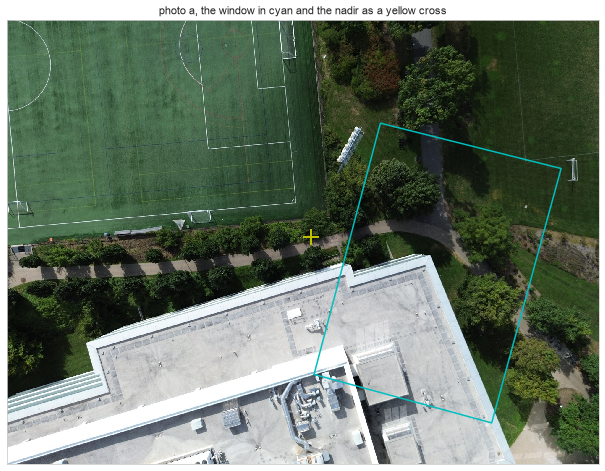

In [3]:
a = choices["photos"]["a"]["shot_index"]
centre_a = sfm.camera_centre(rotation[a], translation[a])
ground = float(np.nanmedian(dtm))
nadir_a = centre_a[:2] + offset
u, v = sfm.project_outline(block, choices, "a", shapely.box(*choices["window"]["bounds"]), ground)
nu, nv = sfm.project_outline(block, choices, "a", shapely.Point(nadir_a).buffer(0.01), ground)
flying_height = centre_a[2] - ground
fig, ax = plt.subplots(figsize=(10.7, 8))
sfm.show_image(ax, image_a, title="photo a, the window in cyan and the nadir as a yellow cross")
ax.plot(u, v, "c-", nu, nv, "y+", markersize=16, markeredgewidth=2)
print(f"the lens was {flying_height:.1f} m over the window's ground"
      f"   reference {reference['ortho']['flying_height_over_window_m']} m")

The cyan outline is the window, turned because the camera's heading was the aircraft's, not north. The yellow cross is the nadir, the point on the ground straight below the lens. Everything tall leans away from that cross, and more so farther out. The lean is the distance from the nadir times the height of the thing, divided by the flying height. The flying height is the lens over the window's ground. Look at the roof, the walls you can see all face the cross.

## Rectification

The cell lays photo a onto the surface model cell by cell and shows the raw photograph around the window beside the result.

the photograph covers 100.0% of the window's cells   reference 100.0%
the tallest things in the window leaned 3.27 m before rectification   reference 3.27 m


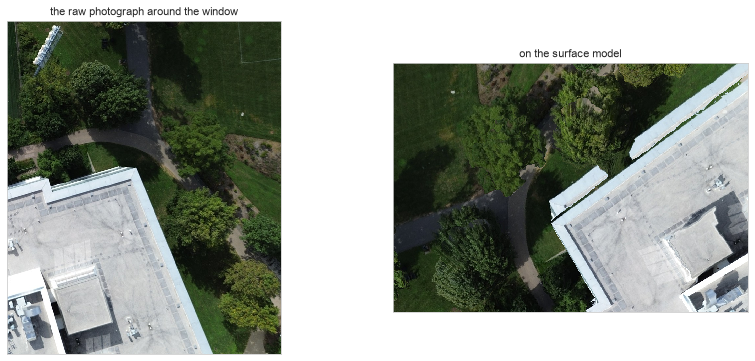

In [4]:
pose_a = rotation[a], translation[a]
ortho_a, covered_a = sfm.orthorectify(dsm, transform, np.nan, image_a, *pose_a, camera, offset)
distance = np.hypot(*(nadir_a - choices["window"]["centre"]))
lean = distance * np.nanpercentile(dsm - dtm, 95) / flying_height
crop = image_a[int(v.min()):int(v.max()), int(u.min()):int(u.max())]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_image(axes[0], crop, title="the raw photograph around the window")
sfm.show_grid(axes[1], ortho_a, transform, title="on the surface model", ticks=False)
print(f"the photograph covers {covered_a.mean():.1%} of the window's cells"
      f"   reference {reference['ortho']['covered_share']:.1%}")
print(f"the tallest things in the window leaned {lean:.2f} m before rectification"
      f"   reference {reference['ortho']['lean_of_p95_height_m']} m")

The pose is where the camera was and how it was turned. Each cell of the surface model is a point in space. Send it through the camera and it lands on one pixel. Put that pixel's colour into the cell. Do this for every cell and the perspective is gone. Read the share of cells the photograph reached, and the lean the surface model has just undone. Compare the roof. On the left it shows a wall, on the right it sits over its footprint.

## A second photograph, and the software's mosaic

The cell rectifies photo b onto the same grid, joins it with photo a by the nearest nadir, and shows the result beside the software's own mosaic.

photo b takes 27.7% of the mosaic   reference 27.7%


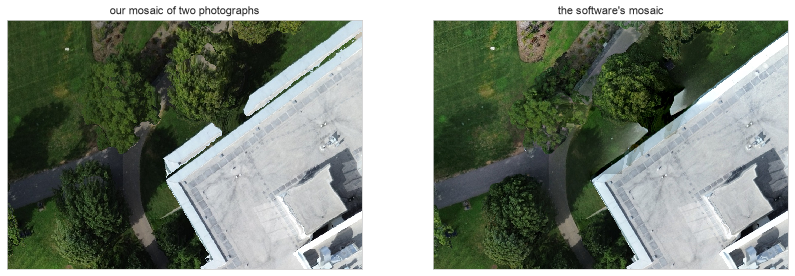

In [5]:
image_b = sfm.read_image("data/photo_b.jpg")
b = choices["photos"]["b"]["shot_index"]
pose_b = rotation[b], translation[b]
ortho_b, covered_b = sfm.orthorectify(dsm, transform, np.nan, image_b, *pose_b, camera, offset)
nadirs = [sfm.camera_centre(*pose)[:2] + offset for pose in (pose_a, pose_b)]
X, Y = sfm.grid_coordinates(transform, dsm.shape)
mosaic, pick = sfm.nearest_nadir_mosaic([ortho_a, ortho_b], [covered_a, covered_b], nadirs, X, Y)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_grid(axes[0], mosaic, transform, title="our mosaic of two photographs", ticks=False)
sfm.show_image(axes[1], sfm.read_raster("data/ortho_window.tif")[0], title="the software's mosaic")
print(f"photo b takes {(pick == 1).mean():.1%} of the mosaic"
      f"   reference {reference['ortho']['two_photograph_mosaic_share_from_b']:.1%}")

A mosaic is several rectified photographs and a rule for which to use where. The nearest nadir is the simplest rule, because the lean is smallest there, and with it every error of the surface model. Read the share the second photograph takes. Its nadir lies farther from the window, so it gets the smaller part. Look for the seam on the lawn. You will not find it, because both photographs were laid onto the same surface. The software's mosaic agrees with ours wherever the surface model is right.

## The terrain model and flat ground

The cell lays photo a onto the terrain model and onto flat ground at the lawn's height, with the roof's footprint in white, and prints the roof's lean.

on flat ground the roof leans 3.66 m away from the nadir   reference 3.66 m


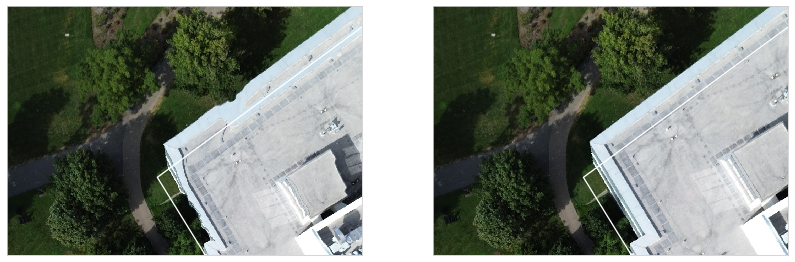

In [6]:
ortho_dtm, _ = sfm.orthorectify(dtm, transform, np.nan, image_a, *pose_a, camera, offset)
flat = np.full_like(dsm, np.nanpercentile(dtm, 25))
ortho_flat, _ = sfm.orthorectify(flat, transform, np.nan, image_a, *pose_a, camera, offset)
roof = sfm.roof_mask(sfm.roof_polygon(choices), transform, dsm.shape)
roof_centre = np.array([X[roof].mean(), Y[roof].mean()])
lean_roof = np.hypot(*(roof_centre - nadir_a)) * sfm.roof_height(dsm, flat, roof) / flying_height
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_grid(axes[0], ortho_dtm, transform, outline=sfm.roof_polygon(choices), ticks=False)
sfm.show_grid(axes[1], ortho_flat, transform, outline=sfm.roof_polygon(choices), ticks=False)
print(f"on flat ground the roof leans {lean_roof:.2f} m away from the nadir"
      f"   reference {reference['ortho']['roof']['lean_on_ground_plane_m']} m")

The State's orthophoto was made this way, on a terrain model. The ground is right and everything above it leans. On the left the roof still sits in its footprint, because the software's terrain model kept it, as 03b-06 found. On the right every cell under the building was given the lawn's height, so the roof's picture slides out of the footprint, away from the nadir, by the lean printed above. Look at the gap between the roof's edge and the white line.

## Your turn

The list names the photographs the mosaic may use. The cell rectifies each one, lets the nearest nadir pick a photograph for every cell, prints the share each takes and draws the seams between them. The default repeats the share photo b took above. Run the cell as it is, then change the marked value and run it again.

Where do the seams fall once the third photograph joins, and why do they fall there? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

photo a takes 72.3% of the mosaic
photo b takes 27.7% of the mosaic


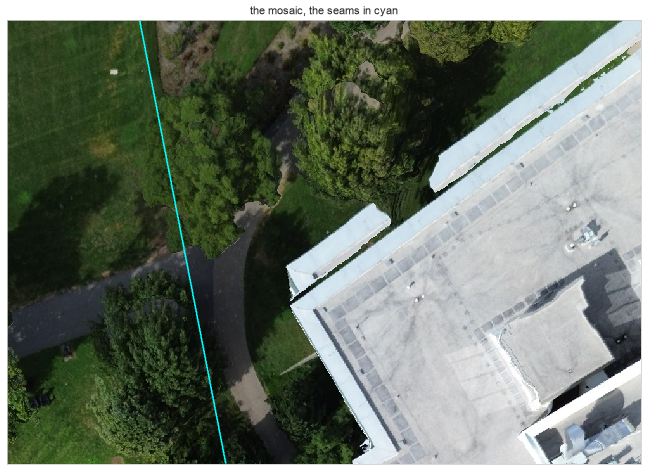

In [7]:
PHOTOS = ["a", "b"]  # change me: ["a", "b", "c"]
shots = [choices["photos"][key]["shot_index"] for key in PHOTOS]
images = [sfm.read_image("data/" + choices["photos"][key]["kit_file"]) for key in PHOTOS]
made = [sfm.orthorectify(dsm, transform, np.nan, image, rotation[s], translation[s], camera, offset)
        for image, s in zip(images, shots)]
nadirs = [sfm.camera_centre(rotation[s], translation[s])[:2] + offset for s in shots]
mosaic, pick = sfm.nearest_nadir_mosaic([m[0] for m in made], [m[1] for m in made], nadirs, X, Y)
fig, ax = plt.subplots(figsize=(11.4, 8))
sfm.show_grid(ax, mosaic, transform, title="the mosaic, the seams in cyan", ticks=False)
ax.contour(X, Y, pick, levels=np.arange(len(PHOTOS) - 1) + 0.5, colors="cyan", linewidths=1.5)
for k, key in enumerate(PHOTOS):
    print(f"photo {key} takes {(pick == k).mean():.1%} of the mosaic")

## Check your understanding

1. A cell of the surface model becomes a pixel of the orthophoto. What must the cell bring, and what must the photograph bring?
2. The roof sits in its footprint on the surface model and slides off it on flat ground. Which height did each surface give the roof's cells, and which pixel followed?
3. Two rectified photographs overlap and a seam must be chosen. Why does the nearest nadir rule break nothing on the lawn, and where would it still break something?
4. An orthophoto made on a terrain model is handed to you. Where can you trust a distance on it, where not, and what formula says by how much?

## Where we are

You made an orthophoto from one photograph, the camera and pose of the block, and the surface model, and the roof stood over its footprint. You now know that a mosaic is rectified photographs plus a rule for the seams, and that an orthophoto made on a terrain model is right on the ground and leaning above it. The seven steps of the pipeline are done, and 03-08 of Precept 03 checks the whole result against distances taped on the ground.

## Further resources

Nothing in this course requires anything below.

- Elements of Photogrammetry with Applications in GIS, Wolf, Dewitt and Wilkinson, McGraw-Hill 2014, chapter 13 on orthophotos and differential rectification.
- Let There Be Color! Large-Scale Texturing of 3D Reconstructions, Waechter, Moehrle and Goesele, ECCV 2014, the texturing the software uses: https://www.gcc.tu-darmstadt.de/home/proj/texrecon/
- Orthophoto resolution, OpenDroneMap documentation, 2025: https://docs.opendronemap.org/arguments/orthophoto-resolution/
- Computer Vision: Algorithms and Applications, Szeliski, Springer 2022, chapter 8 on image stitching, free online: https://szeliski.org/Book/

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0. The outline of Poe Field and the buildings are an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright